In [1]:
# Setup: imports and global configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Use a consistent style for plots
plt.style.use('seaborn-v0_8')

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Utilities: helper functions for analysis
from typing import Optional, Tuple

# Reuse helpers from src.utils
from src.utils.analysis import predict_all, tsne_scatter
from src.utils.interpretability import (
    to_numpy,
    plot_sequence,
    get_attn_token_weights,
    integrated_gradients_token_importance,
    gradient_saliency_token_importance,
    compute_token_importance,
    plot_token_importance,
)


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/reg_mixer_attnpl_t_20260204-161105") 
# checkpoints/reg_mixer_attnpl_t_20260131-114145
checkpoint_path = checkpoint_dir / "last_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_

OptimizedModule(
  (_orig_mod): TaskModel(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Tanh()
          (1): Linear(in_features=1, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (conv1d): Conv1d(384, 384, kernel_size=(4,), stride=(1,), padding=(3,), groups=384)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
              (f

In [4]:
model.eval()
model.extractor.g

Parameter containing:
tensor([-0.0352, -0.0679,  0.0420, -0.0641], device='cuda:0',
       requires_grad=True)

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/regressor/regressor_Mc_3_Mf_3_Tfore_180_Twindow_360_context_le

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [7]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

In [8]:
for x, y in test_loader:
    x, y = x.to(device), y.to(device)

In [9]:
# model.base_model.input_adapter(x)['features'][0,:,0]

In [9]:
model.base_model.input_adapter.mag_mean_gr

tensor(3.5069)

In [10]:
# model.base_model.encoder

In [11]:
model.base_model.encoder.input_proj(model.base_model.input_adapter(x)['features'])[0,0,:]

tensor([ 0.0275, -0.0026,  0.0122, -0.0256, -0.0339,  0.0063,  0.0329,  0.0040,
         0.0014, -0.0221,  0.0009,  0.0229, -0.0430,  0.0019,  0.0162, -0.0001,
         0.0269, -0.0223, -0.0118,  0.0106,  0.0183, -0.0065, -0.0069, -0.0017,
         0.0090, -0.0282, -0.0045,  0.0232,  0.0033,  0.0278, -0.0147,  0.0197,
        -0.0133, -0.0136,  0.0320, -0.0209, -0.0061,  0.0160,  0.0223,  0.0003,
        -0.0082,  0.0128, -0.0056, -0.0210, -0.0388, -0.0143, -0.0036, -0.0213,
        -0.0113, -0.0179, -0.0120,  0.0080,  0.0039,  0.0161, -0.0043,  0.0398,
         0.0249,  0.0025, -0.0397,  0.0113,  0.0190,  0.0062, -0.0294, -0.0260],
       device='cuda:0', grad_fn=<SliceBackward0>)

In [12]:
mag = torch.linspace(3, 7.5, steps=x.shape[1], device=x.device).unsqueeze(0).expand(x.shape[0], -1)
x[:,:,2] = mag

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


mean: 0.0006607489776797593
std : 0.0430402047932148
min : -0.1209554523229599
max : 0.12184396386146545


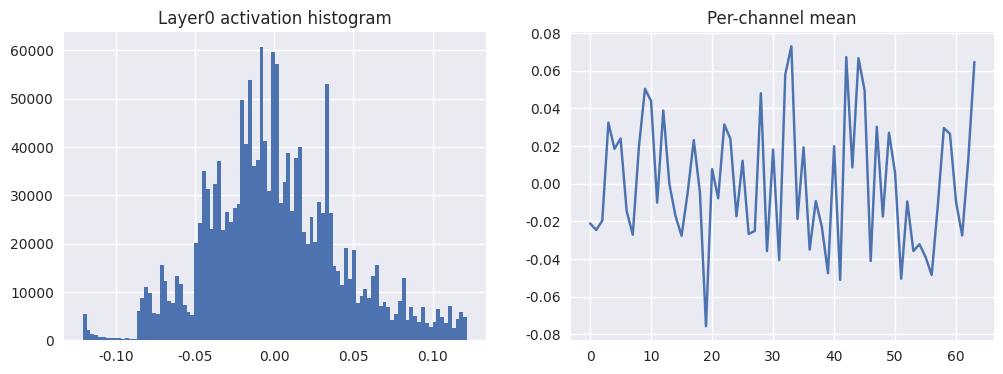

In [13]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]

    layer0_out.append(out.detach().cpu())

# hook_handle = model.base_model.encoder.layers[0].register_forward_hook(_hook)
hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Global stats
    print("mean:", h.mean().item())
    print("std :", h.std().item())
    print("min :", h.min().item())
    print("max :", h.max().item())

    # Per-channel mean
    channel_means = h.mean(dim=(0, 1)).numpy()

    # Flatten histogram
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(h_flat, bins=100)
    plt.title("Layer0 activation histogram")

    plt.subplot(1,2,2)
    plt.plot(channel_means)
    plt.title("Per-channel mean")

    plt.show()
else:
    print("No activations captured.")

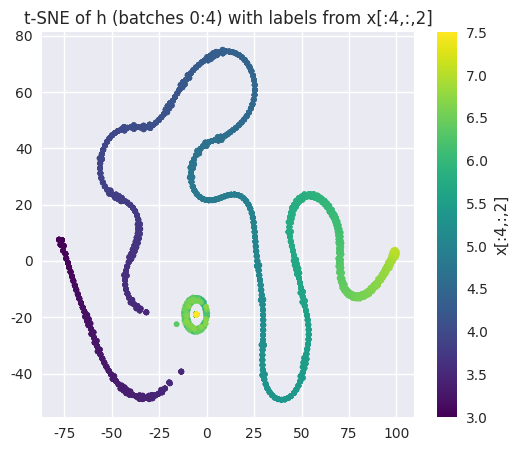

In [14]:
# t-SNE on pooled inputs with labels from batches 0:4
h_np = to_numpy(h[:5]).reshape(-1, h.shape[-1])   # (4*L, D)
labels = to_numpy(x[:5, :, 2]).reshape(-1)        # (4*L,)

X_emb = TSNE(n_components=2, random_state=42).fit_transform(h_np)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap="viridis", s=15)
plt.colorbar(sc, label="x[:4,:,2]")
plt.title("t-SNE of h (batches 0:4) with labels from x[:4,:,2]")
plt.show()

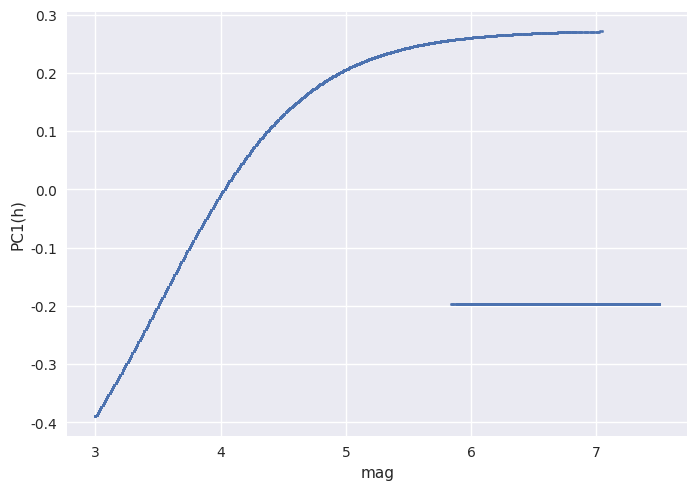

In [15]:
from sklearn.decomposition import PCA
pc1 = PCA(n_components=1).fit_transform(h_np)[:,0]
plt.scatter(labels, pc1, s=3)
plt.xlabel("mag")
plt.ylabel("PC1(h)")
plt.show()


[3.1643643e+02 1.8306506e+00 1.1407681e-01 8.7928660e-03 7.4746390e-04]


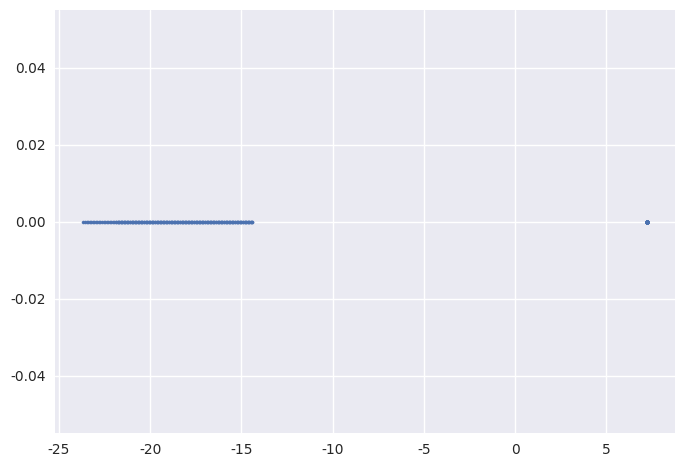

In [ ]:
mask = (labels > 6)
h_hi = h_np[mask]
# 看方差谱
import numpy as np
u, s, v = np.linalg.svd(h_hi - h_hi.mean(0), full_matrices=False)
print(s[:5])
plt.scatter(pc1[mask], np.zeros_like(pc1[mask]), s=5)
plt.show()


In [34]:
# 震级(归一化后的)与 embedding 的线性相关性：如果几乎是 1D，就不会“真断”
from sklearn.decomposition import PCA
z = labels  # (B*L,)
pc1 = PCA(n_components=1).fit_transform(h_np)[:,0]
print("corr(pc1, mag) =", np.corrcoef(pc1, z)[0,1])


corr(pc1, mag) = 0.8689818778209597


In [15]:
model.eval()
model.extractor.t_mlp.to(device)
x_ = torch.linspace(0, 1, 100).unsqueeze(1)  
x_ = x_.to(device)  
gamma, beta = model.extractor.t_mlp(x_).chunk(2, dim=-1)  

In [16]:
# Use the reusable predict_all from src.utils.analysis
from src.utils.analysis import predict_all

In [17]:
from src.utils.metrics import regression_metrics, log_metrics, plot_and_save_roc_curve
y_pred_val, y_val, X_val = predict_all(model,val_loader, device, return_X=True)

start=0
end =400
regression_metrics(y_val[start:end], y_pred_val[start:end])  

{'RMSE': 0.12212649501372914,
 'MAE': 0.09591449600654645,
 'MSE': 0.01491488078433841,
 'MAPE': 21.39012972829546,
 'R2': 0.10180083639471726,
 'PearsonR': 0.5673373548913232,
 'PearsonR_diff': 0.12328147308415488,
 'DA': 0.0718232044198895,
 'SpearmanR': 0.5594355265570645,
 'SpearmanR_diff': 0.1709449165048882,
 'DTW': 11.318878799676895,
 'DTW_normalized': 0.06219164175646646}

In [18]:
X_all = X_val
y_all = y_val
y_pred_all = y_pred_val

/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


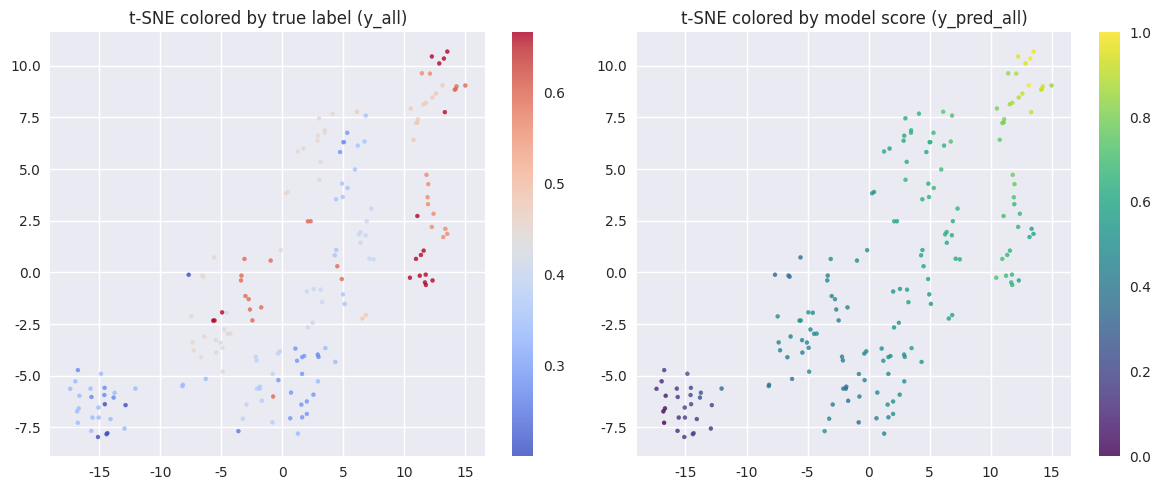

In [19]:
# t-SNE visualization of pooled features
X_scaled, X_tsne, y_score = tsne_scatter(X_all, y_all, y_pred_all)

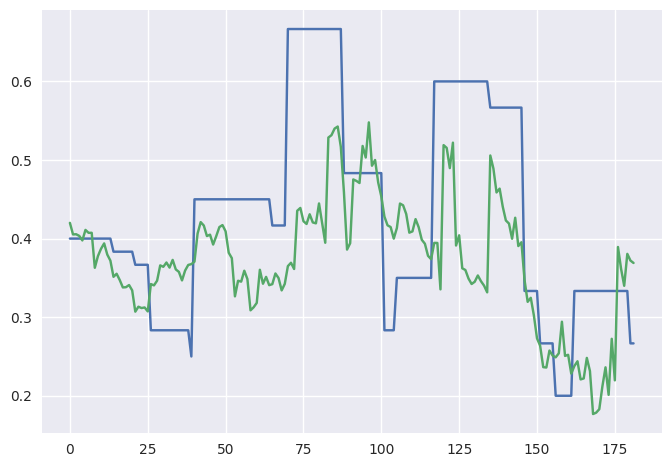

In [20]:
plt.plot(y_all,)
plt.plot(y_pred_all)

In [33]:
xs, ys = [], []
for x, y in test_loader:
    x, y = x.to(device), y.to(device)
    xs.append(x) 
    ys.append(y)

In [22]:
# Token Importance: unified compute function
scores, mask_plot, label = compute_token_importance(model, x, method='ig', n_steps=40)

In [23]:
sample_idx =13

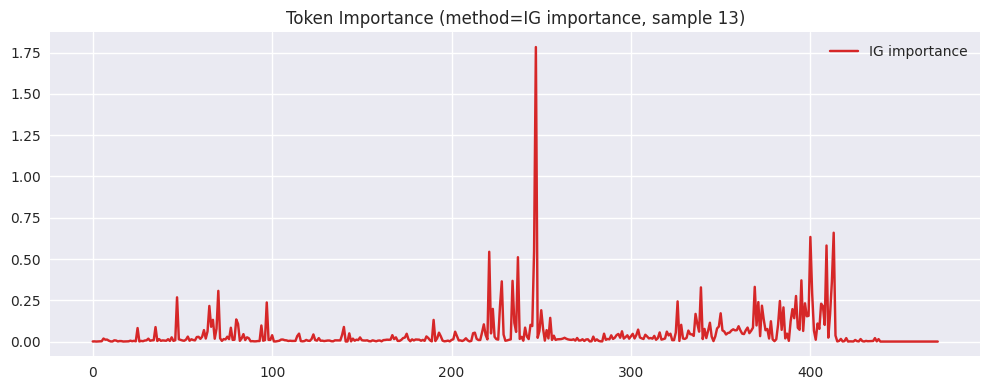

In [24]:
# Plot for the selected sample
plot_token_importance(scores, sample_idx=sample_idx, label=label, mask=mask_plot, color='tab:red')


In [25]:
# x[sample_idx,414,2]

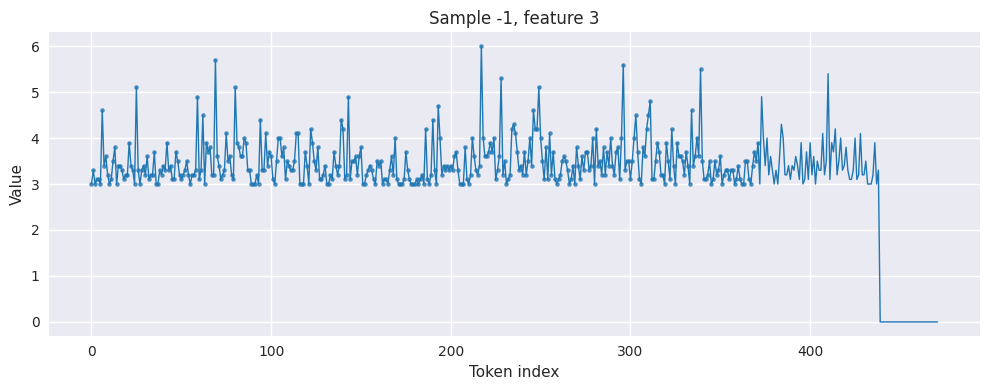

In [26]:
plot_sequence(
    x,
    sample_idx=sample_idx,
    feature_idx=2,
    t=t if 't' in globals() and isinstance(t, np.ndarray) else None,
    title="Sample -1, feature 3",
)

In [27]:
# Import reusable token ranking and deletion validation helpers
from src.utils.interpretability import rank_tokens_numeric, deletion_validation_numeric

In [28]:
# Example: run numeric token ranking + deletion validation on `x` and `scores`
# Assumptions:
# - `x`: tensor [B, L, D] is defined earlier (e.g., batch from test_loader)
# - `scores`: tensor [B, L] computed via `compute_token_importance(model, x, ...)`
# - `sample_idx`: integer index of sample to analyze

import torch

# Validate prerequisites
try:
    _ = x
    _ = scores
    _ = sample_idx
except NameError:
    raise RuntimeError("Please define `x`, `scores`, and `sample_idx` earlier.")

# Build a valid token mask (True = token has non-zero features)
valid_mask = (x[sample_idx].abs().sum(dim=-1) > 0)

# Rank tokens
ranks = rank_tokens_numeric(token_scores=scores, sample_idx=sample_idx, valid_mask=valid_mask, topn=20)
print("Top tokens by importance (index, score):")
for i, (idx, sc) in enumerate(ranks['top'], 1):
    print(f"{i:>2}. idx={idx:<3} score={sc:.6f}")

# Deletion validation with zeroing tokens
validation = deletion_validation_numeric(
    model=model,
    x=x,
    token_scores=scores,
    sample_idx=sample_idx,
    topk_list=(1, 2, 5, 10),
    deletion_mode='zero',            # alternatives: 'baseline', 'noise'
    baseline_strategy='zeros',       # used only when deletion_mode='baseline'
    valid_mask=valid_mask,
    return_details=True,
)

print(f"Baseline prediction: {validation['baseline']:.6f}")
print("Top-k deletion drops:")
for r in validation['results']['topk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")

print("Least-k deletion drops (sanity):")
for r in validation['results']['leastk']:
    print(f"k={r['k']:>2} drop={r['drop']:.6f}")


Top tokens by importance (index, score):
 1. idx=247 score=1.784182
 2. idx=413 score=0.659255
 3. idx=400 score=0.633701
 4. idx=409 score=0.581825
 5. idx=246 score=0.545502
 6. idx=221 score=0.543878
 7. idx=237 score=0.511012
 8. idx=395 score=0.370813
 9. idx=234 score=0.367764
10. idx=228 score=0.364700
11. idx=412 score=0.363957
12. idx=369 score=0.331339
13. idx=339 score=0.328136
14. idx=70  score=0.307065
15. idx=401 score=0.291529
16. idx=392 score=0.276001
17. idx=47  score=0.267888
18. idx=383 score=0.245650
19. idx=326 score=0.243312
20. idx=371 score=0.239159
Baseline prediction: 0.516004
Top-k deletion drops:
k= 1 drop=-0.001413
k= 2 drop=-0.017269
k= 5 drop=0.000234
k=10 drop=0.001815
Least-k deletion drops (sanity):
k= 1 drop=0.000000
k= 2 drop=0.000000
k= 5 drop=0.000000
k=10 drop=0.000000
